In [1]:
import pandas as pd
import numpy as np

# Display settings
pd.set_option('display.max_columns', None)

# Load datasets
client_df = pd.read_excel('../data/raw/clean_data_after_eda.xlsx')
prediction_df = pd.read_excel('../data/raw/data_for_predictions.xlsx')
price_df = pd.read_excel('../data/raw/price_data.xlsx')

In [2]:
# Shape of datasets

print("Client Data Shape:", client_df.shape)
print("Prediction Data Shape:", prediction_df.shape)
print("Price Data Shape:", price_df.shape)

Client Data Shape: (14606, 44)
Prediction Data Shape: (14606, 64)
Price Data Shape: (193002, 8)


In [3]:
# First 5 rows

client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,0.000061,2.627605e-05,0.000440,1.102785,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0.000005,6.089453e-04,0.000000,0.006465,0.000000,0.000000,0.006470,6.089453e-04,0.000000,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0.000006,2.558511e-07,0.000000,0.007662,0.000000,0.000000,0.007668,2.558511e-07,0.000000,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0.000005,0.000000e+00,0.000000,0.006465,0.000000,0.000000,0.006470,0.000000e+00,0.000000,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0.000015,3.552481e-06,0.000003,0.005429,0.001954,0.000869,0.005444,1.957971e-03,0.000871,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


In [4]:
# Dataset information

client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  str           
 1   channel_sales                   14606 non-null  str           
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[us]
 6   date_end                        14606 non-null  datetime64[us]
 7   date_modif_prod                 14606 non-null  datetime64[us]
 8   date_renewal                    14606 non-null  datetime64[us]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  forecast_disc

In [5]:
# Missing values check

client_df.isnull().sum()

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
var_year_price_off_peak_var       0
var_year_price_peak_var           0
var_year_price_mid_peak_var 

In [6]:
# Duplicate rows check

client_df.duplicated().sum()

np.int64(0)

In [7]:
# Statistical summary

client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,1.460600e+04,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,1.460600e+04,14606.000000,14606.000000,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,1.460600e+04,1.460600e+04,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912,2016-07-27 20:48:26.422018,2013-01-02 12:29:10.951663,2015-07-21 06:59:00.353279,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.000041,4.465085e-05,2.084945e-05,6.895442e-01,2.124022,0.885974,0.689585,2.124067e+00,0.885995,0.000025,3.304264e-05,1.406015e-05,0.922810,1.460247,0.634413,0.922835,1.460280e+00,6.344275e-01,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000005,0.000000e+00,0.000000e+00,3.436364e-12,0.000000,0.000000,0.000027,0.000000e+00,0.000000,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000004,0.000000e+00,0.000000e+00,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000009,9.423024e-07,0.000000e+00,6.464760e-03,0.000000,0.000000,0.006470,9.423024e-07,0.000000,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000011,9.450150e-08,0.000000e+00,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000018,4.395760e-06,7.169955e-07,8.380226e-03,0.001448,0.000643,0.008384,1.452014e-03,0.000645,0.000011,2.896760e-06,4.860000e-10,0.007962,0.000000,0.000000,0.007973,2.896760e-06,4.860000e-10,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,0.004758,4.847723e-03,2.610944e-03,3.445652e+02,271.161800,74.761148,344.568812,2.711626e+02,

In [8]:
# Churn distribution

client_df['churn'].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

In [9]:
# Churn percentage

client_df['churn'].value_counts(normalize=True) * 100

churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

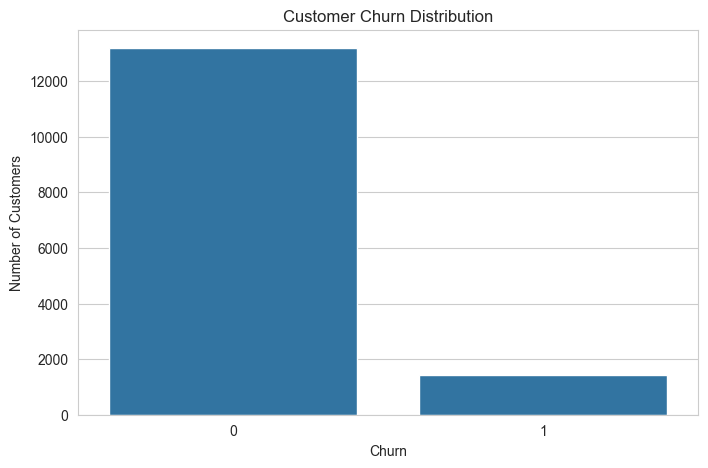

In [11]:
# Churn distribution

sns.countplot(x='churn', data=client_df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

Most customers are retained, while a smaller percentage have churned, indicating class imbalance but also highlighting the importance of identifying high-risk customers early.

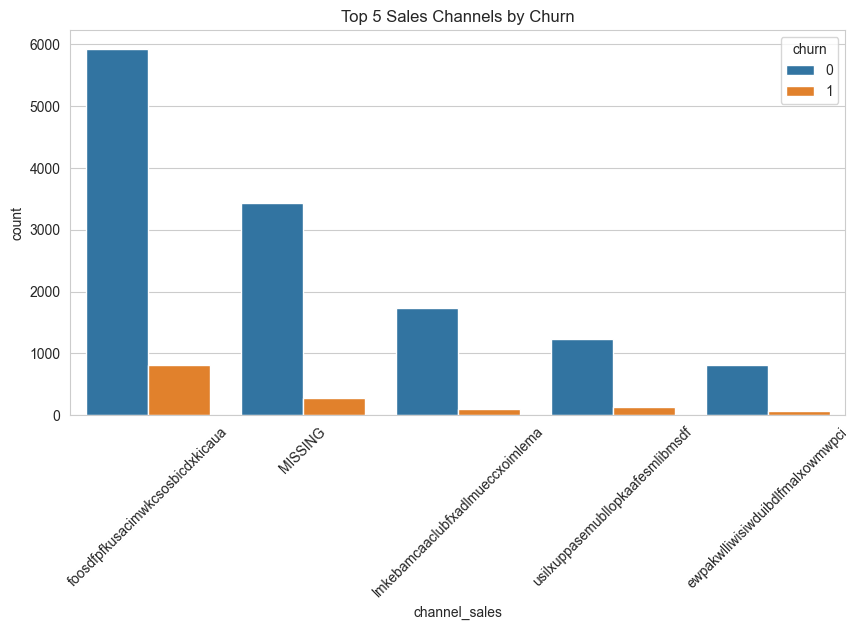

In [14]:
# Top 5 sales channels

top_channels = client_df['channel_sales'].value_counts().head(5).index

filtered_df = client_df[
    client_df['channel_sales'].isin(top_channels)
]

plt.figure(figsize=(10,5))

sns.countplot(
    x='channel_sales',
    hue='churn',
    data=filtered_df
)

plt.title('Top 5 Sales Channels by Churn')
plt.xticks(rotation=45)

plt.show()

Certain sales channels contribute significantly more customers and also exhibit comparatively higher churn levels, suggesting that customer acquisition quality varies across channels.

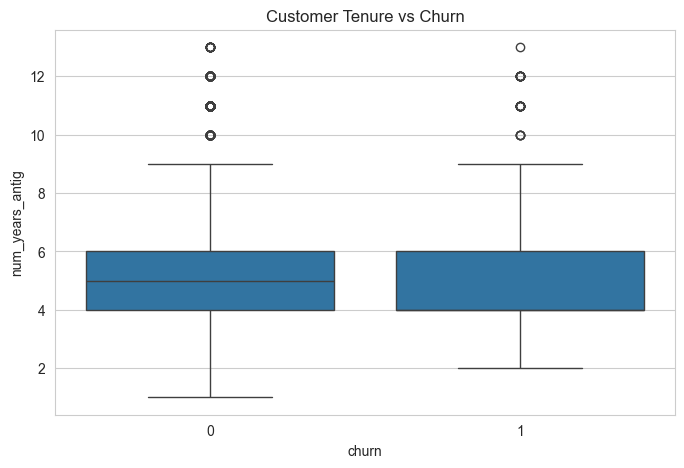

In [13]:
sns.boxplot(
    x='churn',
    y='num_years_antig',
    data=client_df
)

plt.title('Customer Tenure vs Churn')

plt.show()

Customer tenure does not show a major difference between churned and retained customers, suggesting that churn may be influenced more by pricing, service quality, or customer engagement rather than only customer age.

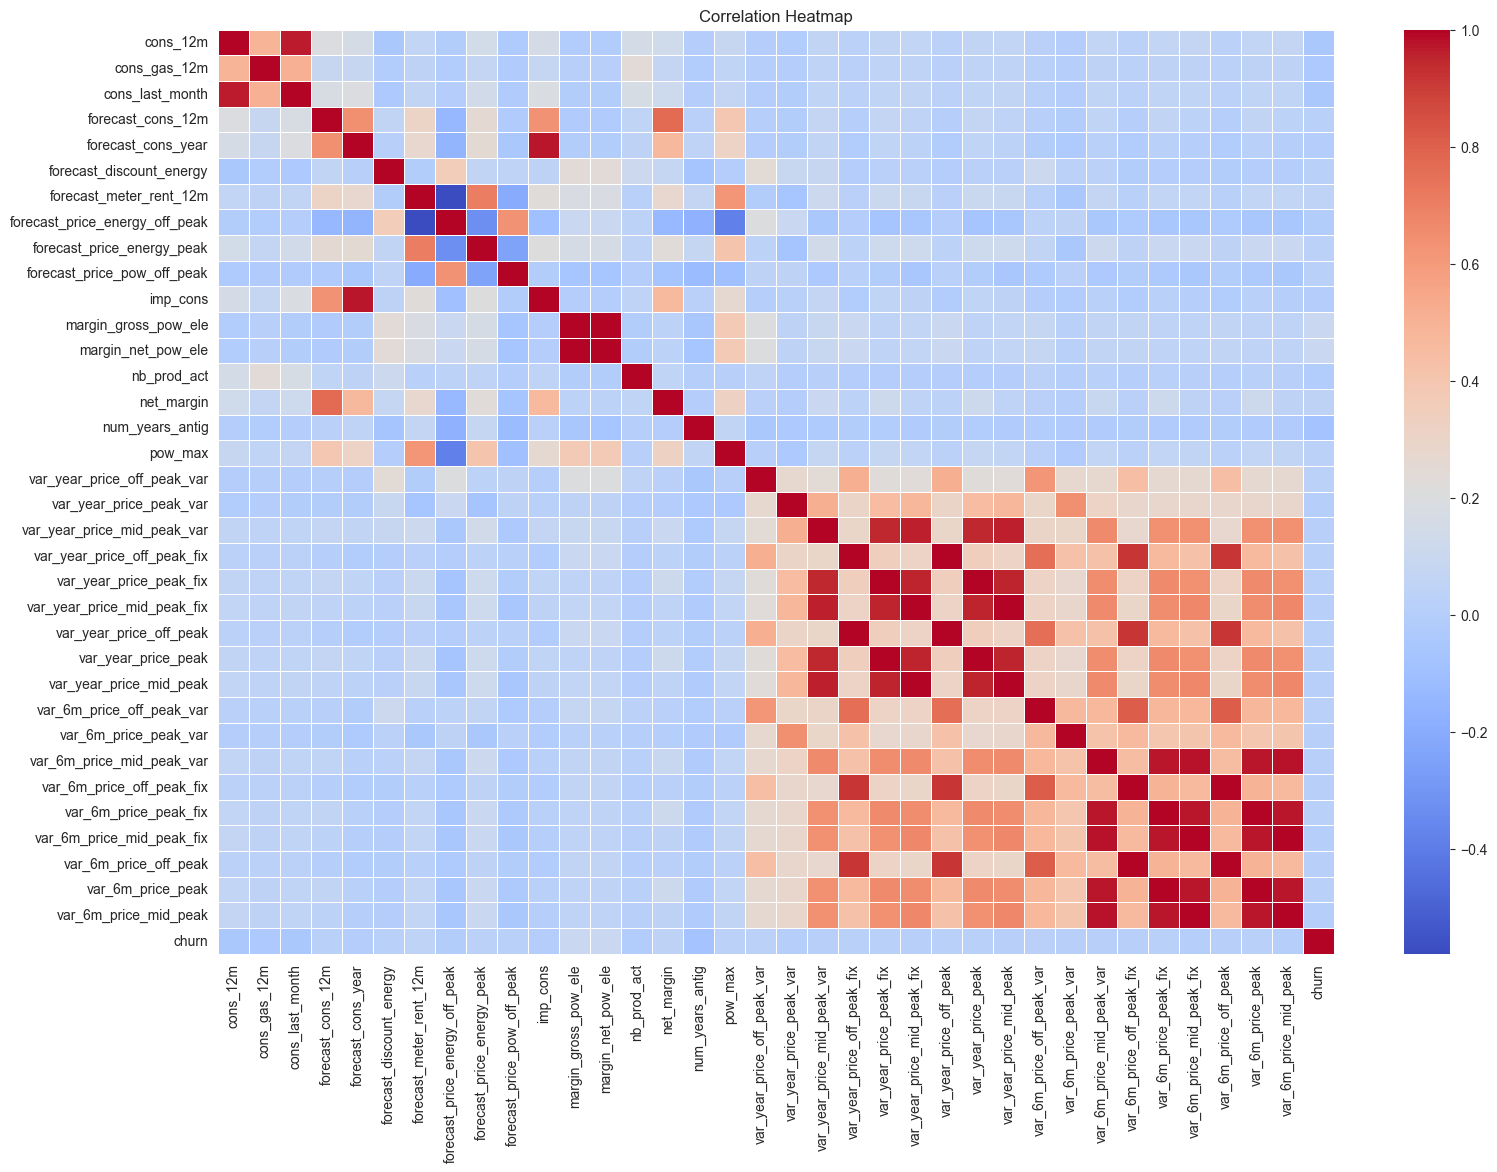

In [15]:
# Correlation heatmap

plt.figure(figsize=(18,12))

correlation_matrix = client_df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

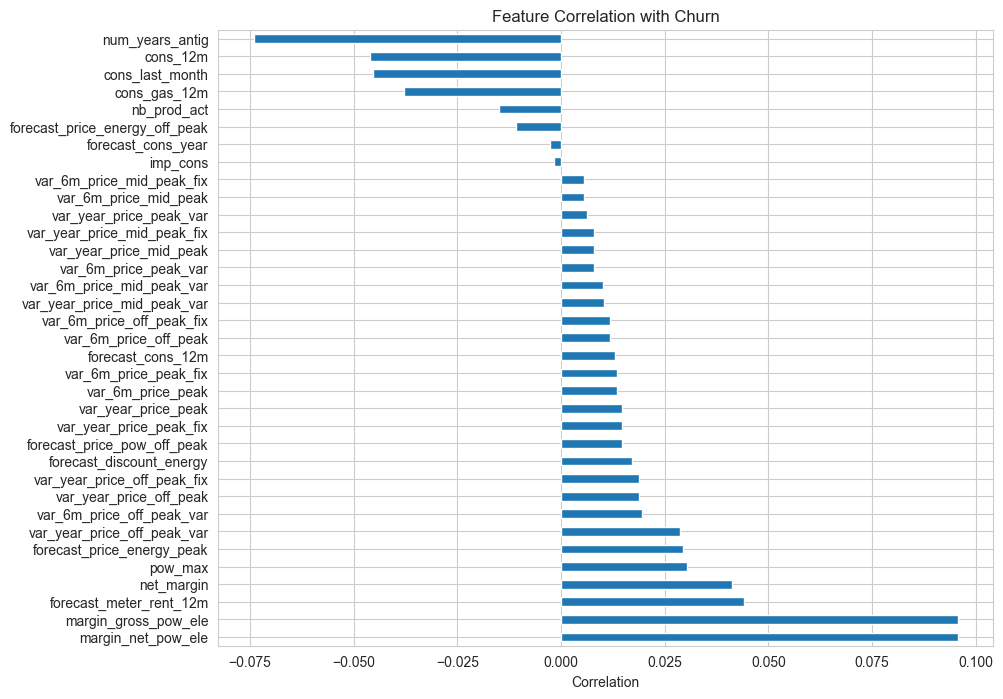

In [16]:
# Correlation of features with churn

churn_corr = correlation_matrix['churn'].sort_values(ascending=False)

plt.figure(figsize=(10,8))

churn_corr.drop('churn').plot(kind='barh')

plt.title('Feature Correlation with Churn')

plt.xlabel('Correlation')

plt.show()

- Instead of comparing EVERYTHING with EVERYTHING
we now compared EVERY feature with ONLY churn
- both positive and negative correlations are important in churn analysis : 

Positive Correlation ----- If a feature increases, churn tendency also increases.

Negative Correlation ----- If a feature increases, churn tendency decreases.
negative correlation helps identify:

loyalty factors
retention drivers
customer stability indicators

Pricing-related variables show positive relationships with churn, indicating that price fluctuations may contribute to customer loss. Customer tenure and consumption variables show negative relationships with churn, suggesting that long-term and high-usage customers are relatively more stable.

In [17]:
# Save cleaned dataset

client_df.to_csv(
    '../data/processed/churn_cleaned.csv',
    index=False
)